In [3]:
import os
import pandas as pd

# Define the CSV and image directory paths
csv_file_path = 'cleaned_train.csv'
image_folder_path = 'Train'

# Load the CSV file
train_csv = pd.read_csv(csv_file_path)

# Add a column with the full file path
train_csv['Path'] = train_csv['ID'].apply(lambda x: os.path.join(image_folder_path, x))

# Check for missing files
missing_files = []
valid_files = []

for img_path in train_csv['Path']:
    if os.path.exists(img_path):
        valid_files.append(img_path)
    else:
        missing_files.append(img_path)

# Log missing files
print(f"Number of valid files: {len(valid_files)}")
print(f"Number of missing files: {len(missing_files)}")
print("Missing files:")
print(missing_files)

# Create a cleaned CSV with only valid files
cleaned_train_csv = train_csv[train_csv['Path'].isin(valid_files)]

# Define the path for the cleaned CSV
cleaned_csv_path = 'path_to_csv/cleaned_train.csv'

# Create the directory if it doesn't exist
cleaned_csv_dir = os.path.dirname(cleaned_csv_path)
if not os.path.exists(cleaned_csv_dir):
    os.makedirs(cleaned_csv_dir)

# Save the cleaned CSV to a new file
cleaned_train_csv.to_csv(cleaned_csv_path, index=False)
print(f"Cleaned CSV saved to: {cleaned_csv_path}")


Number of valid files: 19906
Number of missing files: 0
Missing files:
[]
Cleaned CSV saved to: path_to_csv/cleaned_train.csv


## EDA

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19906 entries, 0 to 19905
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      19906 non-null  object
 1   Class   19906 non-null  object
 2   Path    19906 non-null  object
dtypes: object(3)
memory usage: 466.7+ KB
None

Missing Values:
ID       0
Class    0
Path     0
dtype: int64

Class Distribution:
Class
MIDDLE    10804
YOUNG      6706
OLD        2396
Name: count, dtype: int64


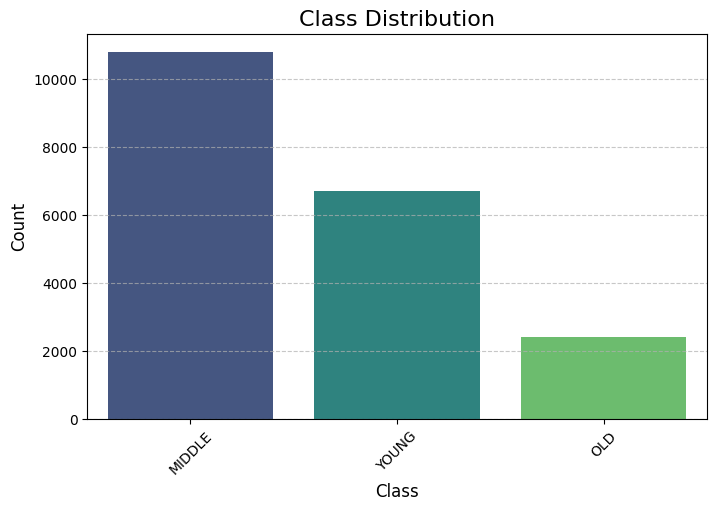

Number of missing files (skipped): 0


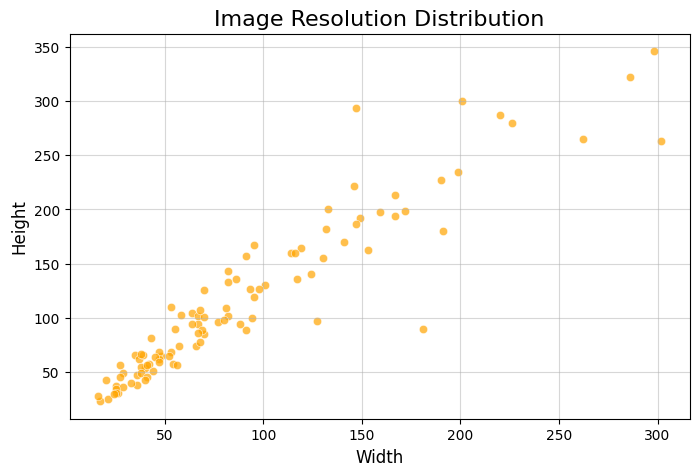

C:\Users\Aneesh Mada\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


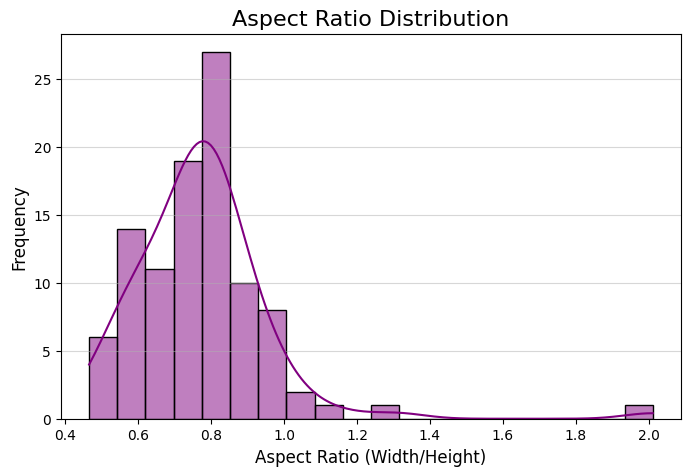


Class-wise Image Resolution Stats:
             Width                 Height           
              mean        std        mean        std
Class                                               
MIDDLE   78.576923  60.058908  102.884615  66.896658
OLD     113.461538  83.232221  128.846154  88.291984
YOUNG    99.571429  63.921959  129.971429  80.411620

Number of Duplicate Entries: 0

Number of Missing Image Files: 0


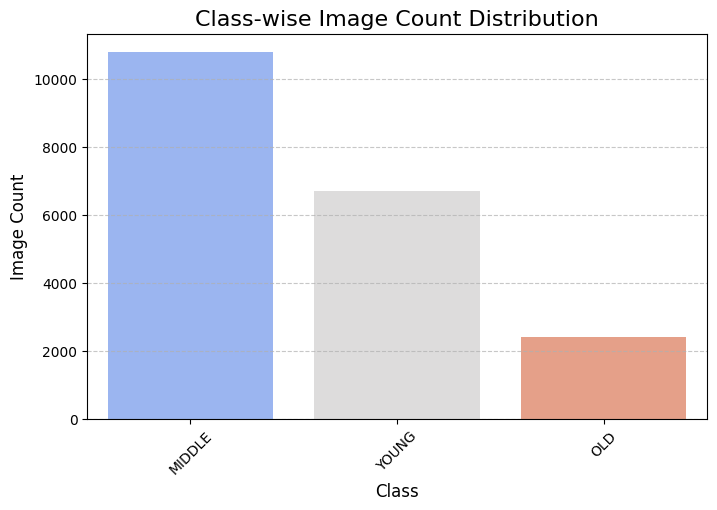

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os

# Load the CSV file
csv_file_path = 'cleaned_train.csv'
train_csv = pd.read_csv(csv_file_path)

# Add a column with the full file path
image_folder_path = 'Train'
train_csv['Path'] = train_csv['ID'].apply(lambda x: os.path.join(image_folder_path, x))

# General dataset info
print("Dataset Overview:")
print(train_csv.info())

# Check for missing values
missing_values = train_csv.isnull().sum()
print("\nMissing Values:")
print(missing_values)

# Analyze class distribution
class_distribution = train_csv['Class'].value_counts()
print("\nClass Distribution:")
print(class_distribution)

# Plot class distribution
plt.figure(figsize=(8, 5))
sns.barplot(x=class_distribution.index, y=class_distribution.values, palette='viridis')
plt.title('Class Distribution', fontsize=16)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Image resolution and aspect ratio analysis
image_resolutions = []
aspect_ratios = []
missing_files_count = 0  # Counter for missing files

for img_path in train_csv['Path'].iloc[:100]:  # Sample 100 images for speed
    try:
        with Image.open(img_path) as img:
            width, height = img.size
            image_resolutions.append((width, height))
            aspect_ratios.append(width / height)
    except FileNotFoundError:
        missing_files_count += 1  # Increment counter for missing files
        continue

# Log the count of missing files
print(f"Number of missing files (skipped): {missing_files_count}")

# Visualize image resolutions
if image_resolutions:
    resolutions_df = pd.DataFrame(image_resolutions, columns=['Width', 'Height'])
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=resolutions_df, x='Width', y='Height', alpha=0.7, color='orange')
    plt.title('Image Resolution Distribution', fontsize=16)
    plt.xlabel('Width', fontsize=12)
    plt.ylabel('Height', fontsize=12)
    plt.grid(alpha=0.5)
    plt.show()

# Aspect ratio analysis
if aspect_ratios:
    plt.figure(figsize=(8, 5))
    sns.histplot(aspect_ratios, kde=True, color='purple', bins=20)
    plt.title('Aspect Ratio Distribution', fontsize=16)
    plt.xlabel('Aspect Ratio (Width/Height)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(axis='y', alpha=0.5)
    plt.show()


# Check class-wise image resolutions (mean and std dev)
if image_resolutions:  # Ensure resolutions_df is defined before using it
    resolutions_df = pd.DataFrame(image_resolutions, columns=['Width', 'Height'])
    resolutions_df['Class'] = train_csv['Class'].iloc[:len(resolutions_df)].values  # Map classes for sampled data
    print("\nClass-wise Image Resolution Stats:")
    print(resolutions_df.groupby('Class')[['Width', 'Height']].agg(['mean', 'std']))
else:
    print("\nNo valid image resolutions to analyze class-wise stats.")


# Check for duplicate entries
duplicates = train_csv.duplicated().sum()
print("\nNumber of Duplicate Entries:", duplicates)

# Check file existence
missing_files = train_csv[~train_csv['Path'].apply(os.path.exists)]
print("\nNumber of Missing Image Files:", len(missing_files))

# Class-wise distribution of image counts
plt.figure(figsize=(8, 5))
sns.countplot(data=train_csv, x='Class', order=class_distribution.index, palette='coolwarm')
plt.title('Class-wise Image Count Distribution', fontsize=16)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Image Count', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## Data Preprocessing

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import os

# Paths and parameters
image_folder_path = 'Train'  # Replace with your image folder
train_csv['Path'] = train_csv['ID'].apply(lambda x: os.path.join(image_folder_path, x))
image_size = (224, 224)
batch_size = 32

# Train-test split
train_data, test_data = train_test_split(train_csv, test_size=0.2, stratify=train_csv['Class'], random_state=42)

# Data generators
train_datagen = ImageDataGenerator(rescale=1.0/255.0, horizontal_flip=True, rotation_range=20)
test_datagen = ImageDataGenerator(rescale=1.0/255.0)

train_generator = train_datagen.flow_from_dataframe(
    train_data, x_col='Path', y_col='Class', target_size=image_size,
    batch_size=batch_size, class_mode='categorical'
)

test_generator = test_datagen.flow_from_dataframe(
    test_data, x_col='Path', y_col='Class', target_size=image_size,
    batch_size=batch_size, class_mode='categorical', shuffle=False
)


Found 15924 validated image filenames belonging to 3 classes.
Found 3982 validated image filenames belonging to 3 classes.


## VGG16 Model

In [8]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

# Load MobileNetV2 base model (smaller and faster than VGG16)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers on top
model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')  # 3 classes
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10,
    steps_per_epoch=train_generator.n // train_generator.batch_size,
    validation_steps=test_generator.n // test_generator.batch_size
)

# Save the model
model.save('mobilenet_model.h5')


Epoch 1/10
497/497 [==============================] - 1983s 4s/step - loss: 0.9347 - accuracy: 0.6108 - val_loss: 0.7988 - val_accuracy: 0.6517
Epoch 2/10
497/497 [==============================] - 21687s 44s/step - loss: 0.7853 - accuracy: 0.6510 - val_loss: 0.7465 - val_accuracy: 0.6746
Epoch 3/10
497/497 [==============================] - 770s 2s/step - loss: 0.7461 - accuracy: 0.6730 - val_loss: 0.7229 - val_accuracy: 0.6807
Epoch 4/10
497/497 [==============================] - 692s 1s/step - loss: 0.7262 - accuracy: 0.6842 - val_loss: 0.7197 - val_accuracy: 0.6893
Epoch 5/10
497/497 [==============================] - 634s 1s/step - loss: 0.7140 - accuracy: 0.6878 - val_loss: 0.7550 - val_accuracy: 0.6683
Epoch 6/10
497/497 [==============================] - 602s 1s/step - loss: 0.6930 - accuracy: 0.6968 - val_loss: 0.7028 - val_accuracy: 0.6998
Epoch 7/10
497/497 [==============================] - 602s 1s/step - loss: 0.6754 - accuracy: 0.7039 - val_loss: 0.7096 - val_accuracy: 0.

In [ ]:
 from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Use MobileNetV2 for a smaller, faster model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Freeze the base layers to avoid retraining them
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers on top
model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')  # 3 classes
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Use ImageDataGenerator for data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Assume you have 'train_dir' and 'test_dir' paths with the dataset
train_generator = train_datagen.flow_from_directory(
    'train_dir',  # Replace with your training data directory
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    'test_dir',  # Replace with your testing data directory
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

# Train the model
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=5,  # Start with fewer epochs
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_steps=test_generator.samples // test_generator.batch_size
)

# Save the model
model.save('VGG16_model.h5')


In [16]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import numpy as np
import seaborn as sns

# Predictions
test_generator.reset()
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Confusion Matrix
conf_matrix = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

# ROC and AUC
fpr, tpr, _ = roc_curve(true_classes, predictions[:, 1], pos_label=1)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Accuracy vs Loss
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()

plt.show()


InvalidArgumentError: Graph execution error:

Detected at node 'sequential_1/dense_2/Relu' defined at (most recent call last):
    File "<frozen runpy>", line 198, in _run_module_as_main
    File "<frozen runpy>", line 88, in _run_code
    File "C:\Users\Aneesh Mada\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
      app.launch_new_instance()
    File "C:\Users\Aneesh Mada\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
      app.start()
    File "C:\Users\Aneesh Mada\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
      self.io_loop.start()
    File "C:\Users\Aneesh Mada\anaconda3\Lib\site-packages\tornado\platform\asyncio.py", line 195, in start
      self.asyncio_loop.run_forever()
    File "C:\Users\Aneesh Mada\anaconda3\Lib\asyncio\windows_events.py", line 321, in run_forever
      super().run_forever()
    File "C:\Users\Aneesh Mada\anaconda3\Lib\asyncio\base_events.py", line 607, in run

In [17]:
import cv2
import tensorflow.keras.backend as K
import numpy as np

def grad_cam(input_model, image, category_index, layer_name):
    grad_model = Model(inputs=input_model.input, outputs=[input_model.get_layer(layer_name).output, input_model.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image)
        loss = predictions[:, category_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = K.mean(grads, axis=(0, 1, 2))

    heatmap = np.mean(conv_outputs.numpy() * pooled_grads.numpy(), axis=-1)[0]
    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)
    return heatmap

# Apply GRAD-CAM
sample_image_path = test_data['Path'].iloc[0]
image = cv2.imread(sample_image_path)
image = cv2.resize(image, (224, 224))
image_input = np.expand_dims(image / 255.0, axis=0)
heatmap = grad_cam(model, image_input, np.argmax(predictions[0]), 'block5_conv3')

# Overlay heatmap on the image
heatmap = cv2.resize(heatmap, (224, 224))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
superimposed_img = cv2.addWeighted(image, 0.6, heatmap, 0.4, 0)

# Display
plt.imshow(superimposed_img)
plt.axis('off')
plt.title('GRAD-CAM')
plt.show()


NameError: name 'predictions' is not defined